# BTC/USDT Time-Series Prediction — Model Experiments with Hyperparameter Tuning

**Objective**: Next-day BTC closing price prediction using 5 models, each with proper hyperparameter search.


**Metrics**: RMSE, MAPE, Directional Accuracy  
**Data**: 3 years daily BTC-USD via Yahoo Finance

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
from itertools import product

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, make_scorer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Statsmodels & pmdarima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

# XGBoost
import xgboost as xgb

# Technical indicators
import ta

# Prophet
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

# MLflow
import mlflow
import mlflow.xgboost
import mlflow.keras
import os
# Pin MLflow tracking to the notebook's directory
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("experiments.ipynb"))
mlflow.set_tracking_uri(f"file:///{NOTEBOOK_DIR}/mlruns")

mlflow.set_experiment("btc_prediction")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras Tuner: {kt.__version__}")
print(f"MLflow: {mlflow.__version__}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Setup complete.")

Importing plotly failed. Interactive plots will not work.
2026/03/15 15:19:24 INFO mlflow.tracking.fluent: Experiment with name 'btc_prediction' does not exist. Creating a new experiment.


TensorFlow: 2.20.0
Keras Tuner: 1.4.8
MLflow: 3.10.1
MLflow tracking URI: file:///c:\Users\sidde\OneDrive\Desktop\BIZ assignment\Backend\experiment/mlruns
Setup complete.


## 2. Data Collection & Cleaning

In [2]:
# Fetch ~3 years of daily BTC-USD data
end_date = datetime.now()
start_date = end_date - timedelta(days=3*365)

print(f"Fetching BTC-USD data from {start_date.date()} to {end_date.date()}...")
df_raw = yf.download('BTC-USD', start=start_date, end=end_date, interval='1d')

# Flatten MultiIndex columns if present
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df = df_raw.copy()

# Handle missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")
df = df.ffill().bfill()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.describe()

Fetching BTC-USD data from 2023-03-16 to 2026-03-15...


[*********************100%***********************]  1 of 1 completed


Missing values: 0
Shape: (1096, 5)
Date range: 2023-03-16 to 2026-03-15


Price,Close,High,Low,Open,Volume
count,1096.000000,1096.000000,1096.000000,1096.000000,1.096000e+03
mean,69279.557877,70436.154903,67992.908037,69235.822011,3.757923e+10
std,29797.276802,30238.333496,29335.338883,29828.299393,2.435390e+10
min,25052.789062,25190.326172,24225.111328,24373.457031,5.331173e+09
25%,41763.598633,42368.686523,40674.541016,41659.763672,1.835668e+10
50%,67598.984375,68723.957031,66234.035156,67580.445312,3.244591e+10
75%,95576.507812,96902.855469,94004.123047,95581.138672,4.962452e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


## 3. Exploratory Data Analysis

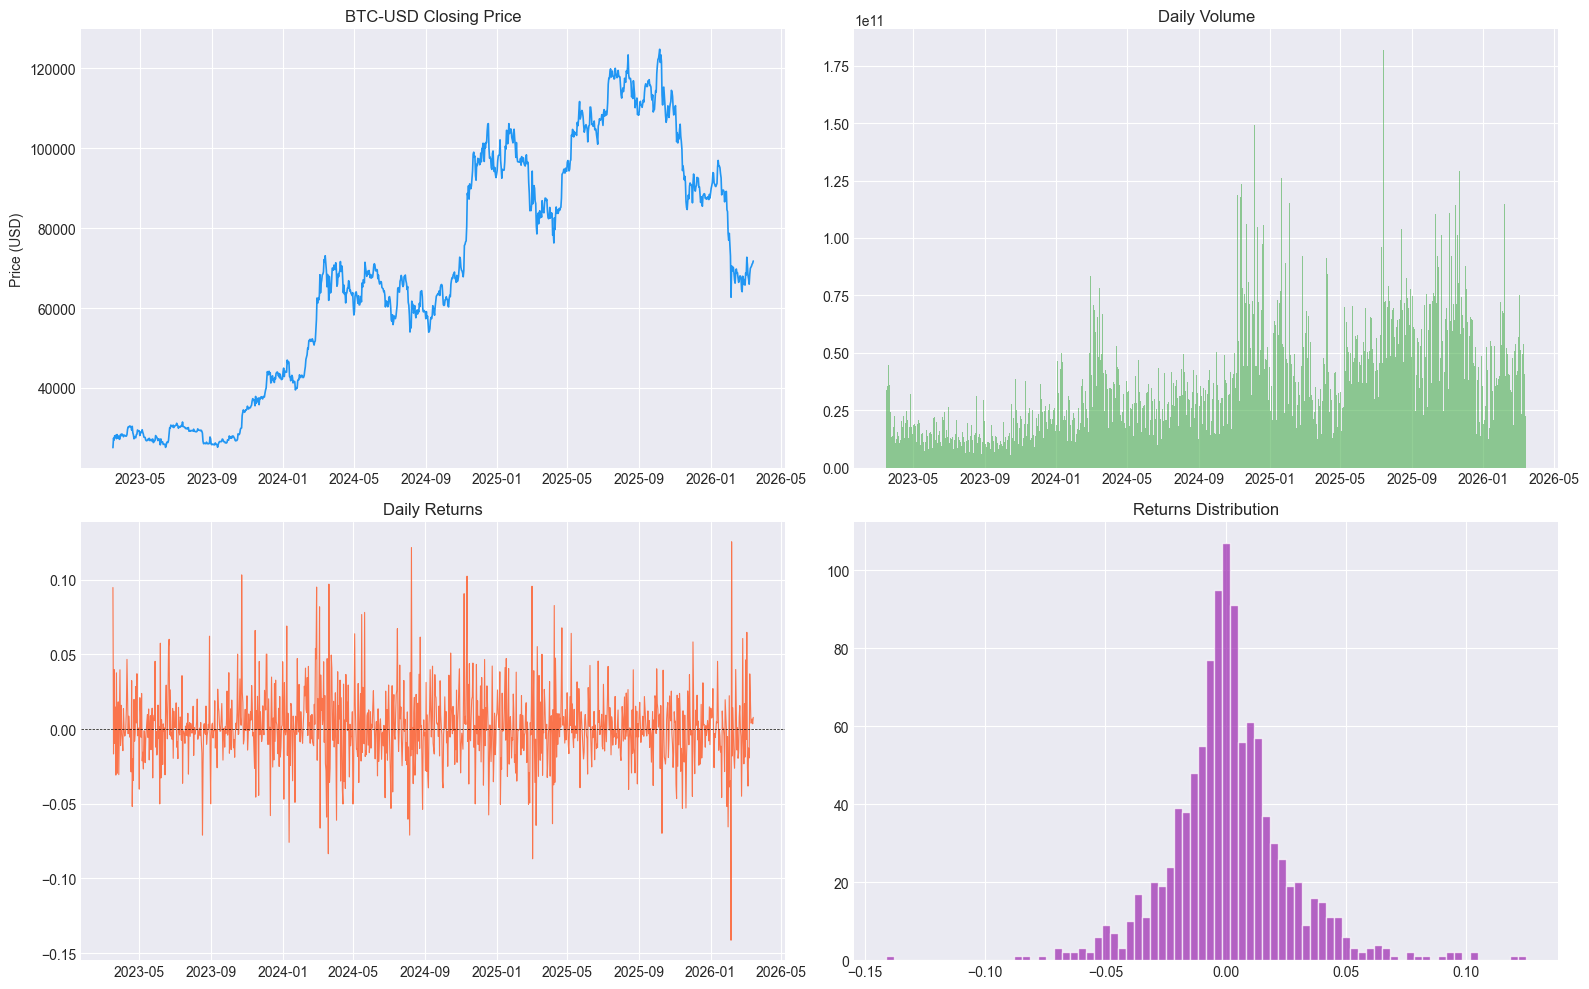

ADF Test — p-value: 0.5515 (Non-stationary -> needs differencing)
ADF Test (1st diff) — p-value: 0.000000 (Stationary)


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(df.index, df['Close'], color='#2196F3', linewidth=1.2)
axes[0, 0].set_title('BTC-USD Closing Price')
axes[0, 0].set_ylabel('Price (USD)')

axes[0, 1].bar(df.index, df['Volume'], color='#4CAF50', alpha=0.6, width=1)
axes[0, 1].set_title('Daily Volume')

daily_returns = df['Close'].pct_change()
axes[1, 0].plot(df.index, daily_returns, color='#FF5722', linewidth=0.8, alpha=0.8)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1, 0].set_title('Daily Returns')

axes[1, 1].hist(daily_returns.dropna(), bins=80, color='#9C27B0', alpha=0.7, edgecolor='white')
axes[1, 1].set_title('Returns Distribution')

plt.tight_layout()
plt.savefig('btc_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Stationarity check
result = adfuller(df['Close'].dropna())
print(f"ADF Test — p-value: {result[1]:.4f} ({'Stationary' if result[1] < 0.05 else 'Non-stationary -> needs differencing'})")
diff_result = adfuller(df['Close'].diff().dropna())
print(f"ADF Test (1st diff) — p-value: {diff_result[1]:.6f} ({'Stationary' if diff_result[1] < 0.05 else 'Non-stationary'})")

## 4. Feature Engineering (Lags + Rolling Stats + Technical Indicators)

In [4]:
def create_features(data):
    """Create lag, rolling, and technical indicator features."""
    df_feat = data.copy()
    close, high, low, volume = df_feat['Close'], df_feat['High'], df_feat['Low'], df_feat['Volume']
    
    # Lag features
    for lag in range(1, 8):
        df_feat[f'close_lag_{lag}'] = close.shift(lag)
    
    # Rolling statistics
    for window in [7, 14, 21]:
        df_feat[f'sma_{window}'] = close.rolling(window).mean()
        df_feat[f'rolling_std_{window}'] = close.rolling(window).std()
    
    # EMAs
    for span in [7, 21]:
        df_feat[f'ema_{span}'] = close.ewm(span=span).mean()
    
    # Returns & Volatility
    df_feat['return_1d'] = close.pct_change(1)
    df_feat['return_3d'] = close.pct_change(3)
    df_feat['return_7d'] = close.pct_change(7)
    df_feat['volatility_7d'] = df_feat['return_1d'].rolling(7).std()
    df_feat['volatility_21d'] = df_feat['return_1d'].rolling(21).std()
    
    # Price ratios
    df_feat['high_low_ratio'] = high / low
    df_feat['close_open_ratio'] = close / df_feat['Open']
    df_feat['day_of_week'] = df_feat.index.dayofweek
    
    # --- Technical Indicators ---
    df_feat['rsi_14'] = ta.momentum.RSIIndicator(close, window=14).rsi()
    
    macd = ta.trend.MACD(close, window_slow=26, window_fast=12, window_sign=9)
    df_feat['macd'] = macd.macd()
    df_feat['macd_signal'] = macd.macd_signal()
    df_feat['macd_histogram'] = macd.macd_diff()
    
    bb = ta.volatility.BollingerBands(close, window=20, window_dev=2)
    df_feat['bb_upper'] = bb.bollinger_hband()
    df_feat['bb_lower'] = bb.bollinger_lband()
    df_feat['bb_width'] = bb.bollinger_wband()
    df_feat['bb_pct'] = bb.bollinger_pband()
    
    df_feat['atr_14'] = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range()
    
    stoch = ta.momentum.StochasticOscillator(high, low, close, window=14, smooth_window=3)
    df_feat['stoch_k'] = stoch.stoch()
    df_feat['stoch_d'] = stoch.stoch_signal()
    
    df_feat['obv'] = ta.volume.OnBalanceVolumeIndicator(close, volume).on_balance_volume()
    df_feat['volume_sma_7'] = volume.rolling(7).mean()
    df_feat['volume_ratio'] = volume / df_feat['volume_sma_7']
    
    # Target: next-day close
    df_feat['target'] = close.shift(-1)
    return df_feat

df_features = create_features(df).dropna()
feature_cols = [c for c in df_features.columns if c not in ['Open','High','Low','Close','Adj Close','Volume','target']]

print(f"Dataset: {df_features.shape[0]} rows, {len(feature_cols)} features")
print(f"Date range: {df_features.index.min().date()} -> {df_features.index.max().date()}")
print(f"\nFeatures: {feature_cols}")

Dataset: 1062 rows, 37 features
Date range: 2023-04-18 -> 2026-03-14

Features: ['close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_4', 'close_lag_5', 'close_lag_6', 'close_lag_7', 'sma_7', 'rolling_std_7', 'sma_14', 'rolling_std_14', 'sma_21', 'rolling_std_21', 'ema_7', 'ema_21', 'return_1d', 'return_3d', 'return_7d', 'volatility_7d', 'volatility_21d', 'high_low_ratio', 'close_open_ratio', 'day_of_week', 'rsi_14', 'macd', 'macd_signal', 'macd_histogram', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'atr_14', 'stoch_k', 'stoch_d', 'obv', 'volume_sma_7', 'volume_ratio']


In [5]:
df_features.head()

Price,Close,High,Low,Open,Volume,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,sma_7,rolling_std_7,sma_14,rolling_std_14,sma_21,rolling_std_21,ema_7,ema_21,return_1d,return_3d,return_7d,volatility_7d,volatility_21d,high_low_ratio,close_open_ratio,day_of_week,rsi_14,macd,macd_signal,macd_histogram,bb_upper,bb_lower,bb_width,bb_pct,atr_14,stoch_k,stoch_d,obv,volume_sma_7,volume_ratio,target
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-04-18,30397.552734,30470.302734,29154.849609,29449.091797,19480529496,29445.044922,30315.355469,30318.496094,30485.699219,30399.066406,30139.052734,30235.058594,30214.323940,355.870361,29415.509766,1071.007021,29011.727586,1051.191056,29997.931275,29283.514212,0.032349,0.002608,0.005374,0.018201,0.018141,1.045120,1.032207,1,65.647792,839.183930,804.035882,35.148049,31125.185467,26964.598322,14.324678,0.825113,926.000842,81.387112,71.977373,111116616346,1.727827e+10,1.127459,28822.679688
2023-04-19,28822.679688,30411.054688,28669.898438,30394.187500,24571565421,30397.552734,29445.044922,30315.355469,30318.496094,30485.699219,30399.066406,30139.052734,30026.270647,638.138173,29461.559431,1026.645730,29034.310361,1041.276468,29704.105926,29240.074397,-0.051809,-0.049238,-0.043677,0.027117,0.020341,1.060731,0.948296,2,50.262391,708.704362,784.969578,-76.265216,31115.778903,27052.916605,13.969240,0.435595,984.226228,33.179384,55.874147,86545050925,1.812393e+10,1.355753,28245.988281
2023-04-20,28245.988281,29076.400391,28037.257812,28823.683594,21340360360,28822.679688,30397.552734,29445.044922,30315.355469,30318.496094,30485.699219,30399.066406,29718.688058,895.498115,29475.977121,1006.427264,29044.425874,1032.059598,29339.564928,29146.681756,-0.020008,-0.040722,-0.070827,0.026692,0.020696,1.037063,0.979958,3,46.010086,552.396504,738.454963,-186.058459,31120.484459,27024.961439,14.087167,0.298137,988.148825,14.072748,42.879748,65204690565,1.867431e+10,1.142766,27276.910156
2023-04-21,27276.910156,28349.968750,27177.365234,28249.230469,20759504330,28245.988281,28822.679688,30397.552734,29445.044922,30315.355469,30318.496094,30485.699219,29260.289621,1205.167385,29429.623605,1094.412216,28987.208054,1096.312247,28823.888943,28971.552250,-0.034309,-0.102661,-0.105256,0.027367,0.021712,1.043146,0.965581,4,39.901137,346.332588,660.030488,-313.697900,31192.685571,26839.347828,15.003223,0.100512,1001.324160,2.600278,16.617470,44445186235,1.840281e+10,1.128062,27817.500000
2023-04-22,27817.500000,27872.142578,27169.570312,27265.894531,13125734602,27276.910156,28245.988281,28822.679688,30397.552734,29445.044922,30315.355469,30318.496094,28903.004464,1209.878969,29420.316825,1108.446902,28958.944475,1119.318479,28572.287209,28863.756505,0.019819,-0.034875,-0.082491,0.030404,0.022218,1.025859,1.020231,5,44.340745,224.063667,572.837124,-348.773457,31208.332073,26785.520466,15.252691,0.233331,979.984739,16.890600,11.187875,57570920837,1.857210e+10,0.706745,27591.384766


## 5. Train/Test Split & Evaluation Helpers

In [ ]:
# Time-aware split — last 60 days for test (NO shuffling)
TEST_DAYS = 60
split_idx = len(df_features) - TEST_DAYS

train_data = df_features.iloc[:split_idx]
test_data  = df_features.iloc[split_idx:]

X_train, y_train = train_data[feature_cols], train_data['target']
X_test,  y_test  = test_data[feature_cols],  test_data['target']

print(f"Train: {train_data.index.min().date()} -> {train_data.index.max().date()} ({len(train_data)} days)")
print(f"Test: {test_data.index.min().date()} -> {test_data.index.max().date()} ({len(test_data)} days)")
print(f"Features: {X_train.shape[1]}")

def evaluate_model(y_true, y_pred, model_name):
    """RMSE, MAPE, and Directional Accuracy. Logs to MLflow if a run is active."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    actual_dir = np.sign(np.diff(np.concatenate([[y_true.iloc[0]], y_true.values])))
    pred_dir   = np.sign(np.diff(np.concatenate([[y_true.iloc[0]], y_pred])))
    dir_acc = np.mean(actual_dir[1:] == pred_dir[1:]) * 100

    print(f"\n{'='*55}")
    print(f"{model_name}")
    print(f"{'='*55}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Directional Accuracy: {dir_acc:.1f}%")

    if mlflow.active_run():
        mlflow.log_metrics({"RMSE": rmse, "MAPE": mape, "Dir_Accuracy": dir_acc})

    return {'model': model_name, 'RMSE': rmse, 'MAPE': mape, 'Dir_Accuracy': dir_acc}

all_results = []
all_predictions = {}
best_params = {}  # store best hyperparameters per model

Train: 2023-04-18 -> 2026-01-13 (1002 days)
Test:  2026-01-14 -> 2026-03-14 (60 days)
Features: 37


---
## 6. ARIMA — auto_arima (Stepwise Grid Search over p,d,q)

auto_arima from pmdarima performs a stepwise search over ARIMA orders (p,d,q), selecting the best combination by AIC/BIC. This is the ARIMA equivalent of GridSearchCV.

In [ ]:
%%time
mlflow.end_run() 
mlflow.start_run(run_name="ARIMA")

# auto_arima — searches (p,d,q) space using AIC
close_series = df['Close'].copy()
feat_offset = len(df) - len(df_features)
train_close = close_series.iloc[:split_idx + feat_offset]

print("Searching optimal ARIMA order (p,d,q)...")
auto_model = auto_arima(
    train_close,
    start_p=1, start_q=1,
    max_p=15, max_q=15, max_d=5,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
    error_action='ignore',
    information_criterion='aic'
)

best_order = auto_model.order
print(f"\n✓ Best order: ARIMA{best_order}")
print(f"  AIC: {auto_model.aic():.2f}")
best_params['ARIMA'] = {'order': best_order, 'AIC': auto_model.aic()}

mlflow.log_params({
    "order_p": best_order[0],
    "order_d": best_order[1],
    "order_q": best_order[2],
    "AIC": round(auto_model.aic(), 2),
})

In [ ]:
# Rolling one-step-ahead forecast with the best ARIMA order
test_start = split_idx + feat_offset
history = list(train_close.values)
arima_preds = []

print(f"Rolling ARIMA{best_order} forecast for {len(y_test)} steps...")
for i in range(len(y_test)):
    try:
        model = ARIMA(history, order=best_order)
        yhat = model.fit().forecast(steps=1)[0]
        arima_preds.append(yhat)
    except:
        arima_preds.append(history[-1])

    idx = test_start + i
    if idx < len(close_series):
        history.append(close_series.iloc[idx])
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(y_test)} done")

arima_preds = np.array(arima_preds[:len(y_test)])
res = evaluate_model(y_test, arima_preds, f"ARIMA{best_order}")
all_results.append(res)
all_predictions['ARIMA'] = arima_preds

mlflow.end_run()

Rolling ARIMA(0, 1, 0) forecast for 60 steps...
  20/60 done
  40/60 done
  60/60 done

  ARIMA(0, 1, 0)
RMSE: $2,514.41
MAPE: 2.32%
Directional Accuracy: 57.6%
CPU times: total: 656 ms
Wall time: 1.19 s


---
## 7. XGBoost — GridSearchCV + TimeSeriesSplit

Proper time-series cross-validation using TimeSeriesSplit (expanding window), ensuring no future data leaks into validation folds.

In [ ]:
mlflow.end_run()
mlflow.start_run(run_name="XGBoost")

mlflow.sklearn.autolog(log_models=False, max_tuning_runs=None)

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [300, 400, 500, 600, 700, 800, 900],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1.0, 2.0],
    'min_child_weight': [3, 5],
}

xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0)
scorer = make_scorer(mean_squared_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

print(f"\n✓ Best XGBoost params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"  Best CV RMSE: ${np.sqrt(-grid_search.best_score_):,.2f}")

best_params['XGBoost'] = grid_search.best_params_

mlflow.sklearn.autolog(disable=True)
mlflow.log_params(grid_search.best_params_)
mlflow.log_metric("CV_RMSE", np.sqrt(-grid_search.best_score_))


  XGBoost
RMSE: $4,171.44
MAPE: 4.32%
Directional Accuracy: 57.6%


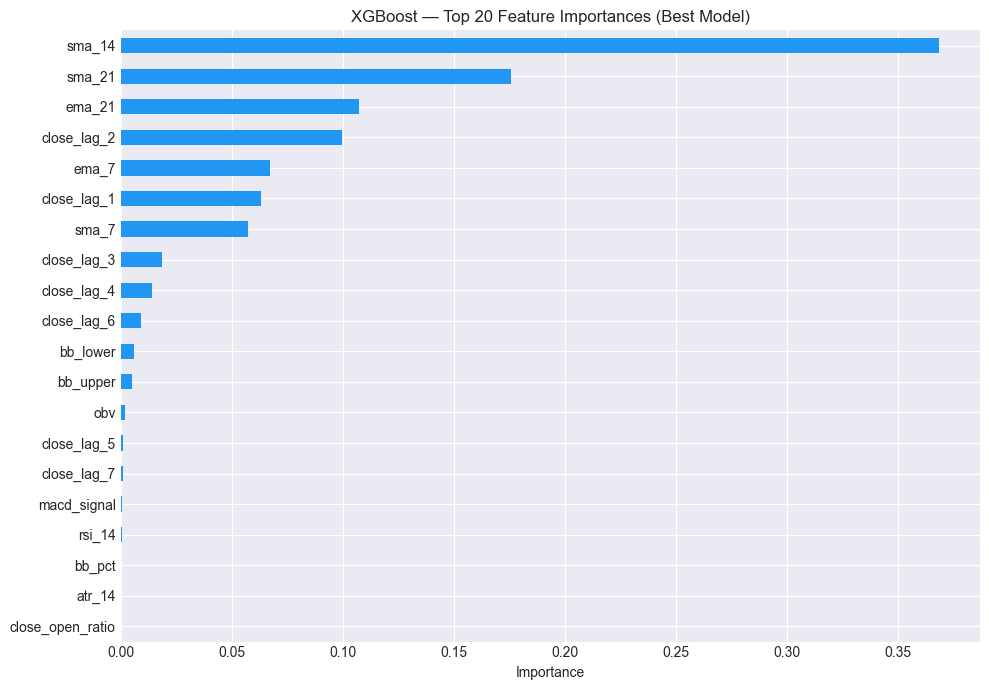

2026/03/15 16:52:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [10]:
# Evaluate best XGBoost on test set
xgb_best = grid_search.best_estimator_
xgb_preds = xgb_best.predict(X_test)

res = evaluate_model(y_test, xgb_preds, "XGBoost")
all_results.append(res)
all_predictions['XGBoost'] = xgb_preds

# Feature importance
importance = pd.Series(xgb_best.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
importance.tail(20).plot(kind='barh', ax=ax, color='#2196F3')
ax.set_title('XGBoost — Top 20 Feature Importances (Best Model)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

mlflow.log_artifact('xgb_feature_importance.png')
mlflow.xgboost.log_model(xgb_best, artifact_path="model")
mlflow.end_run()

---
## 8. LSTM — KerasTuner Bayesian Optimization

KerasTuner searches over LSTM architecture hyperparameters (units, layers, dropout, learning rate) using Bayesian optimization. Scalers are fit **only on training data** to prevent data leakage.

In [ ]:
# Prepare sequences — scalers fit ONLY on training data
SEQ_LEN = 30

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = df_features[feature_cols].values
y_all = df_features['target'].values.reshape(-1, 1)

# Split BEFORE scaling
X_train_raw, X_test_raw = X_all[:split_idx], X_all[split_idx:]
y_train_raw, y_test_raw = y_all[:split_idx], y_all[split_idx:]

# Fit on train only, transform both
scaler_X.fit(X_train_raw)
scaler_y.fit(y_train_raw)

X_train_sc = scaler_X.transform(X_train_raw)
X_test_sc = scaler_X.transform(X_test_raw)
y_train_sc = scaler_y.transform(y_train_raw)
y_test_sc = scaler_y.transform(y_test_raw)

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_sc, y_train_sc, SEQ_LEN)

# For test: use buffer from end of training for continuity
buffer_X = X_train_sc[-SEQ_LEN:]
buffer_y = y_train_sc[-SEQ_LEN:]
X_test_combined = np.vstack([buffer_X, X_test_sc])
y_test_combined = np.vstack([buffer_y, y_test_sc])
X_test_seq, y_test_seq = create_sequences(X_test_combined, y_test_combined, SEQ_LEN)

n_features = X_train_seq.shape[2]
print(f"Sequence shapes — Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")
print(f"Scalers fit on training data only (no leakage)")

Sequence shapes — Train: (972, 30, 37), Test: (60, 30, 37)
Scalers fit on training data only (no leakage)


In [ ]:
%%time
mlflow.end_run()
mlflow.start_run(run_name="LSTM")

def build_lstm(hp):
    model = keras.Sequential()

    units_1 = hp.Choice('lstm_units_1', [64, 128, 256])
    use_bidir = hp.Boolean('bidirectional')

    lstm_layer = layers.LSTM(units_1, return_sequences=True, input_shape=(SEQ_LEN, n_features))
    if use_bidir:
        model.add(layers.Bidirectional(lstm_layer))
    else:
        model.add(lstm_layer)

    if hp.Boolean('use_batchnorm_1'):
        model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Choice('dropout_1', [0.1, 0.2, 0.3])))

    units_2 = hp.Choice('lstm_units_2', [32, 64, 128])
    model.add(layers.LSTM(units_2, return_sequences=hp.Boolean('third_lstm')))
    if hp.Boolean('use_batchnorm_2'):
        model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Choice('dropout_2', [0.1, 0.2, 0.3])))

    if hp.get('third_lstm'):
        model.add(layers.LSTM(hp.Choice('lstm_units_3', [16, 32]), return_sequences=False))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(hp.Choice('dense_units', [16, 32, 64]), activation='relu'))
    model.add(layers.Dropout(hp.Choice('dropout_dense', [0.1, 0.2])))
    model.add(layers.Dense(1))

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
    loss = hp.Choice('loss', ['mse', 'huber'])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss=loss)
    return model

# Subclass the tuner to hook into on_trial_end — correct KerasTuner API
class MLflowBayesianOptimization(kt.BayesianOptimization):
    def on_trial_end(self, trial):
        super().on_trial_end(trial)
        with mlflow.start_run(run_name=f"LSTM_trial_{trial.trial_id}", nested=True):
            mlflow.log_params(trial.hyperparameters.values)
            best_val = trial.metrics.get_best_value("val_loss")
            if best_val is not None:
                mlflow.log_metric("val_loss", best_val)

lstm_tuner = MLflowBayesianOptimization(
    build_lstm,
    objective='val_loss',
    max_trials=20,
    num_initial_points=5,
    directory='tuner_logs',
    project_name='lstm_btc',
    overwrite=True
)

lstm_tuner.search(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
    verbose=0
)

lstm_best_hp = lstm_tuner.get_best_hyperparameters(1)[0]
print("\n Best LSTM hyperparameters:")
for key in lstm_best_hp.values:
    print(f"  {key}: {lstm_best_hp.get(key)}")

best_params['LSTM'] = {k: lstm_best_hp.get(k) for k in lstm_best_hp.values}
mlflow.log_params(best_params['LSTM'])



✓ Best LSTM hyperparameters:
  lstm_units_1: 64
  bidirectional: False
  use_batchnorm_1: False
  dropout_1: 0.1
  lstm_units_2: 32
  third_lstm: False
  use_batchnorm_2: False
  dropout_2: 0.1
  dense_units: 16
  dropout_dense: 0.1
  learning_rate: 0.0001
  loss: huber
  lstm_units_3: 16
CPU times: total: 6min 30s
Wall time: 9min 16s


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0585 - val_loss: 0.0133 - learning_rate: 1.0000e-04
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0165 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0108 - val_loss: 0.0013 - learning_rate: 1.0000e-04
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0086 - val_loss: 0.0010 - learning_rate: 1.0000e-04
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0085 - val_loss: 0.0011 - learning_rate: 1.0000e-04
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0082 - val_loss: 0.0010 - learning_rate: 1.0000e-04
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0065 - val_loss: 0.0010 - learning_rate: 1.0000e-04
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0062 - val_loss: 9.4620e-04 - learning_rate: 1.0000e-04
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0065 - val_loss: 0.001

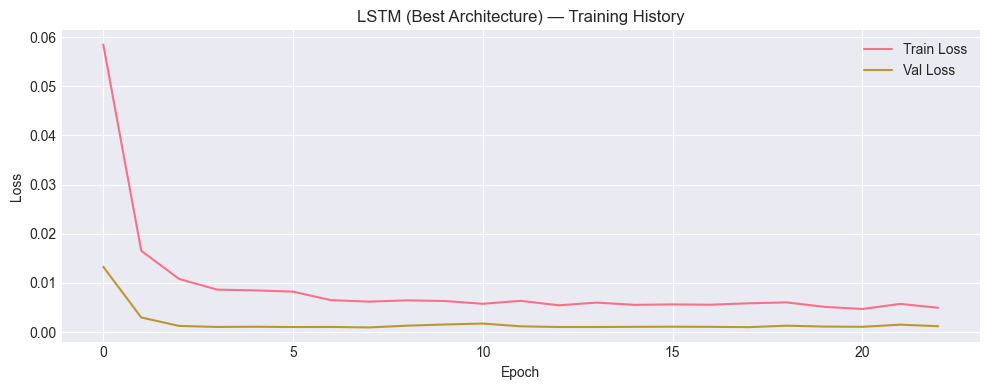

2026/03/15 17:49:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 17:49:52 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



  LSTM
RMSE: $6,100.28
MAPE: 6.04%
Directional Accuracy: 49.2%


In [18]:
# Train best LSTM model — autolog captures epoch-by-epoch train/val loss
mlflow.keras.autolog(log_models=False)

lstm_best = lstm_tuner.get_best_models(1)[0]
lstm_best_fresh = build_lstm(lstm_best_hp)
history_lstm = lstm_best_fresh.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6),
    ],
    verbose=1
)

mlflow.keras.autolog(disable=True)

# Training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_lstm.history['loss'], label='Train Loss')
ax.plot(history_lstm.history['val_loss'], label='Val Loss')
ax.set_title('LSTM (Best Architecture) — Training History')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate
lstm_preds_sc = lstm_best_fresh.predict(X_test_seq, verbose=0)
lstm_preds = scaler_y.inverse_transform(lstm_preds_sc).flatten()
min_len = min(len(lstm_preds), len(y_test))

res = evaluate_model(y_test.iloc[:min_len], lstm_preds[:min_len], "LSTM")
all_results.append(res)
all_predictions['LSTM'] = lstm_preds[:min_len]

mlflow.log_artifact('lstm_training_history.png')
mlflow.keras.log_model(lstm_best_fresh, artifact_path="model")
mlflow.end_run()

---
## 9. Prophet — Manual Parameter Grid + Cross-Validation

Prophet doesn't support sklearn's API, so we use itertools.product over a parameter grid and Prophet's built-in cross_validation for time-series CV.

In [19]:
%%time
mlflow.end_run()
mlflow.start_run(run_name="Prophet")

prophet_param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [1, 5, 10],
    'changepoint_range': [0.8, 0.9],
    'seasonality_mode': ['additive', 'multiplicative'],
}

prophet_df = pd.DataFrame({
    'ds': train_data.index,
    'y': train_data['Close'].values,
})

keys = list(prophet_param_grid.keys())
combos = list(product(*prophet_param_grid.values()))

print(f"Testing {len(combos)} parameter combinations...")
prophet_cv_results = []

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    try:
        m = Prophet(
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=True,
            **params
        )
        m.fit(prophet_df)

        cv_df = cross_validation(m, initial='730 days', period='30 days', horizon='30 days')
        perf = performance_metrics(cv_df)

        rmse = perf['rmse'].mean()
        mape = perf['mape'].mean() * 100
        prophet_cv_results.append({'params': params, 'rmse': rmse, 'mape': mape})

        with mlflow.start_run(run_name=f"Prophet_combo_{i}", nested=True):
            mlflow.log_params(params)
            mlflow.log_metrics({"CV_RMSE": rmse, "CV_MAPE": mape})

        if (i+1) % 8 == 0:
            print(f"  {i+1}/{len(combos)} — current best RMSE: ${min(r['rmse'] for r in prophet_cv_results):,.0f}")
    except Exception as e:
        continue

best_prophet = min(prophet_cv_results, key=lambda x: x['rmse'])
print(f"\n✓ Best Prophet params (CV RMSE: ${best_prophet['rmse']:,.2f}):")
for k, v in best_prophet['params'].items():
    print(f"  {k}: {v}")

best_params['Prophet'] = best_prophet['params']

mlflow.log_params(best_prophet['params'])
mlflow.log_metric("CV_RMSE", best_prophet['rmse'])
mlflow.log_metric("CV_MAPE", best_prophet['mape'])

Testing 48 parameter combinations...


17:50:24 - cmdstanpy - INFO - Chain [1] start processing
17:50:24 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]17:50:24 - cmdstanpy - INFO - Chain [1] start processing
17:50:24 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:02,  2.95it/s]17:50:25 - cmdstanpy - INFO - Chain [1] start processing
17:50:25 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:02,  3.30it/s]17:50:25 - cmdstanpy - INFO - Chain [1] start processing
17:50:25 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  3.44it/s]17:50:25 - cmdstanpy - INFO - Chain [1] start processing
17:50:25 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:01<00:01,  3.40it/s]17:50:25 - cmdstanpy - INFO - Chain [1] start processing
17:50:26 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:01<00:01,  3.40it/s]17:50:26 - cmdstanpy - INFO - Chain [1] start processing
17:

  8/48 — current best RMSE: $20,350


17:50:59 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]17:50:59 - cmdstanpy - INFO - Chain [1] start processing
17:50:59 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:02,  3.19it/s]17:51:00 - cmdstanpy - INFO - Chain [1] start processing
17:51:00 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:00<00:02,  2.89it/s]17:51:00 - cmdstanpy - INFO - Chain [1] start processing
17:51:00 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:01,  3.02it/s]17:51:00 - cmdstanpy - INFO - Chain [1] start processing
17:51:00 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:01<00:01,  3.21it/s]17:51:01 - cmdstanpy - INFO - Chain [1] start processing
17:51:01 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:01<00:01,  3.29it/s]17:51:01 - cmdstanpy - INFO - Chain [1] start processing
17:51:01 - cmdstanpy - INFO - Chain [1] done processing
 67%

  16/48 — current best RMSE: $11,963


...

  32/48 — current best RMSE: $11,209


17:54:18 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]17:54:18 - cmdstanpy - INFO - Chain [1] start processing
17:54:18 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:04,  1.90it/s]17:54:18 - cmdstanpy - INFO - Chain [1] start processing
17:54:19 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:01<00:03,  1.85it/s]17:54:19 - cmdstanpy - INFO - Chain [1] start processing
17:54:19 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:01<00:03,  1.95it/s]17:54:19 - cmdstanpy - INFO - Chain [1] start processing
17:54:20 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:02<00:02,  1.90it/s]17:54:20 - cmdstanpy - INFO - Chain [1] start processing
17:54:20 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:02<00:02,  1.94it/s]17:54:21 - cmdstanpy - INFO - Chain [1] start processing
17:54:21 - cmdstanpy - INFO - Chain [1] done processing
 67%

  40/48 — current best RMSE: $10,603


17:55:38 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/9 [00:00<?, ?it/s]17:55:39 - cmdstanpy - INFO - Chain [1] start processing
17:55:39 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:04,  1.80it/s]17:55:39 - cmdstanpy - INFO - Chain [1] start processing
17:55:40 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 2/9 [00:01<00:04,  1.74it/s]17:55:40 - cmdstanpy - INFO - Chain [1] start processing
17:55:40 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:01<00:03,  1.74it/s]17:55:40 - cmdstanpy - INFO - Chain [1] start processing
17:55:41 - cmdstanpy - INFO - Chain [1] done processing
 44%|████▍     | 4/9 [00:02<00:03,  1.58it/s]17:55:41 - cmdstanpy - INFO - Chain [1] start processing
17:55:42 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:03<00:02,  1.45it/s]17:55:42 - cmdstanpy - INFO - Chain [1] start processing
17:55:42 - cmdstanpy - INFO - Chain [1] done processing
 67%

  48/48 — current best RMSE: $10,603

✓ Best Prophet params (CV RMSE: $10,603.17):
  changepoint_prior_scale: 0.5
  seasonality_prior_scale: 1
  changepoint_range: 0.9
  seasonality_mode: additive
CPU times: total: 43 s
Wall time: 6min 33s


17:59:22 - cmdstanpy - INFO - Chain [1] start processing
17:59:23 - cmdstanpy - INFO - Chain [1] done processing



  Prophet
RMSE: $21,837.03
MAPE: 28.50%
Directional Accuracy: 49.2%


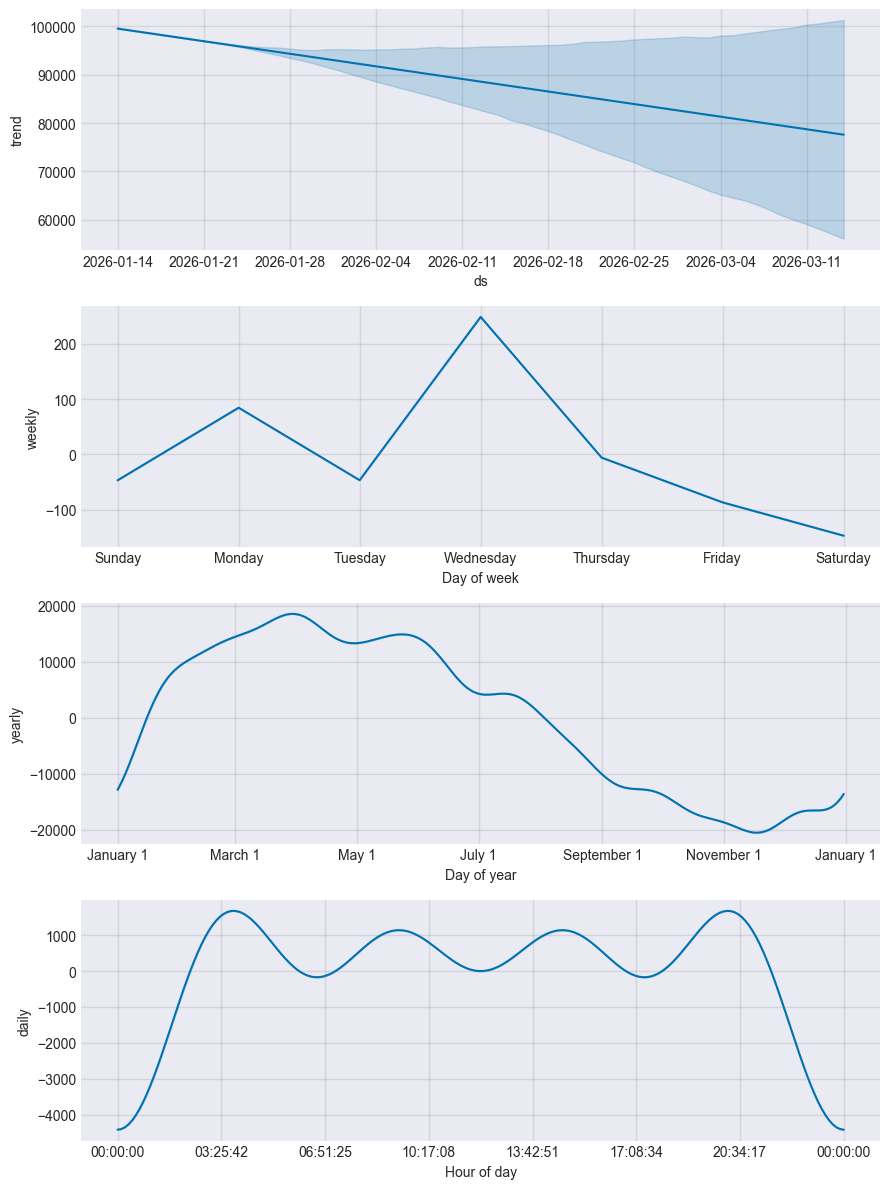

In [20]:
# Evaluate best Prophet on test set
prophet_best = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    **best_prophet['params']
)
prophet_best.fit(prophet_df)

future = pd.DataFrame({'ds': test_data.index})
forecast = prophet_best.predict(future)
prophet_preds = forecast['yhat'].values[:len(y_test)]

res = evaluate_model(y_test, prophet_preds, "Prophet")
all_results.append(res)
all_predictions['Prophet'] = prophet_preds

# Component plot
fig = prophet_best.plot_components(forecast)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

mlflow.log_artifact('prophet_components.png')
mlflow.end_run()

---
## 10. Transformer — Fine-tune IBM Granite PatchTST (HuggingFace)

Fine-tune IBM's pre-trained PatchTST model.

- **Model**: ibm-granite/granite-timeseries-patchtst
- **Architecture**: Patch Time Series Transformer — segments time series into patches, encodes via Transformer
- **Pre-trained on**: ETTh1 dataset (electrical transformer data)
- **Fine-tuned on**: BTC-USD closing price (our data)
- **Key params tuned**: context_length, forecast_horizon, patch_length, learning_rate, num_train_epochs

In [21]:
from transformers import (
    PatchTSTConfig,
    PatchTSTForPrediction,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index

# --- Prepare BTC data for PatchTST ---
# PatchTST expects: a DataFrame with a timestamp column and target columns
btc_ts = df[['Close']].copy()
btc_ts = btc_ts.reset_index()
btc_ts.columns = ['date', 'Close']
btc_ts['date'] = pd.to_datetime(btc_ts['date'])

# Train/test split (same 60-day holdout)
n_total = len(btc_ts)
n_test = TEST_DAYS
n_valid = 30  # 30 days for validation
n_train = n_total - n_test - n_valid

train_ts = btc_ts.iloc[:n_train]
valid_ts = btc_ts.iloc[n_train:n_train + n_valid]
test_ts  = btc_ts.iloc[n_train + n_valid:]

print(f"PatchTST data split:")
print(f"  Train: {len(train_ts)} days ({train_ts['date'].iloc[0].date()} -> {train_ts['date'].iloc[-1].date()})")
print(f"  Valid: {len(valid_ts)} days")
print(f"  Test:  {len(test_ts)} days ({test_ts['date'].iloc[0].date()} -> {test_ts['date'].iloc[-1].date()})")


PatchTST data split:
  Train: 1006 days (2023-03-16 -> 2025-12-15)
  Valid: 30 days
  Test:  60 days (2026-01-15 -> 2026-03-15)


In [22]:
%%time
mlflow.end_run()
mlflow.start_run(run_name="PatchTST")

forecast_columns = ["Close"]
context_length = 516
forecast_horizon = 1
patch_length = 12

tsp = TimeSeriesPreprocessor(
    timestamp_column="date",
    id_columns=[],
    target_columns=forecast_columns,
    scaling=True,
)
tsp.train(train_ts)

full_processed = tsp.preprocess(btc_ts)

train_df = select_by_index(full_processed, start_index=0, end_index=n_train)
valid_df = select_by_index(full_processed, start_index=n_train - context_length, end_index=n_train + n_valid)
test_df  = select_by_index(full_processed, start_index=n_train + n_valid - context_length)

train_dataset = ForecastDFDataset(
    train_df, id_columns=[], target_columns=forecast_columns,
    context_length=context_length, prediction_length=forecast_horizon,
)
valid_dataset = ForecastDFDataset(
    valid_df, id_columns=[], target_columns=forecast_columns,
    context_length=context_length, prediction_length=forecast_horizon,
)
test_dataset = ForecastDFDataset(
    test_df, id_columns=[], target_columns=forecast_columns,
    context_length=context_length, prediction_length=forecast_horizon,
)

print(f"Dataset sizes — Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

config = PatchTSTConfig(
    num_input_channels=len(forecast_columns),
    context_length=context_length,
    patch_length=patch_length,
    patch_stride=patch_length,
    prediction_length=forecast_horizon,
    d_model=128,
    num_attention_heads=16,
    num_hidden_layers=3,
    ffn_dim=512,
    dropout=0.2,
    head_dropout=0.2,
    pooling_type=None,
    channel_attention=False,
    scaling="std",
    loss="mse",
    pre_norm=True,
    norm_type="batchnorm",
    do_mask_input=False,
)

patchtst_model = PatchTSTForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-patchtst",
    config=config,
    ignore_mismatched_sizes=True,
)

print(f"\nModel loaded: ibm-granite/granite-timeseries-patchtst")
print(f"  Context: {context_length} days | Forecast: {forecast_horizon} day | Patch: {patch_length}")
print(f"  Params: {sum(p.numel() for p in patchtst_model.parameters()):,}")

training_args = TrainingArguments(
    output_dir="./patchtst_btc_finetune/",
    overwrite_output_dir=True,
    num_train_epochs=50,
    learning_rate=1e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3,
    label_names=["future_values"],
    report_to="mlflow",
)

trainer = Trainer(
    model=patchtst_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=15, early_stopping_threshold=0.00001)],
)

trainer.train()
print("\nFine-tuning complete!")

mlflow.log_params({
    "pretrained_model": "ibm-granite/granite-timeseries-patchtst",
    "context_length": context_length,
    "forecast_horizon": forecast_horizon,
    "patch_length": patch_length,
    "d_model": 128,
    "num_attention_heads": 16,
    "num_hidden_layers": 3,
    "ffn_dim": 512,
    "learning_rate": 1e-4,
    "num_train_epochs": 50,
    "early_stopping_patience": 15,
})

Dataset sizes — Train: 490, Valid: 30, Test: 60


Some weights of PatchTSTForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-patchtst and are newly initialized because the shapes did not match:
- head.projection.bias: found shape torch.Size([96]) in the checkpoint and torch.Size([1]) in the model instantiated
- head.projection.weight: found shape torch.Size([96, 128]) in the checkpoint and torch.Size([1, 5504]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model loaded: ibm-granite/granite-timeseries-patchtst
  Context: 516 days | Forecast: 1 day | Patch: 12
  Params: 607,489


Epoch,Training Loss,Validation Loss
1,0.270400,0.360901
2,0.035500,0.030725
3,0.028000,0.013625
4,0.036700,0.097785
5,0.023800,0.089726
6,0.021300,0.066613
7,0.019800,0.067565
8,0.015600,0.024049
9,0.015900,0.139175
10,0.017500,0.102098



Fine-tuning complete!
CPU times: total: 45.7 s
Wall time: 29.6 s


In [ ]:
# PatchTST: Evaluate on test set
import torch

# Get predictions
output = trainer.predict(test_dataset)
preds_scaled = output.predictions[0]  # (samples, forecast_horizon, channels)

# Inverse-transform predictions back to original scale
scaler_params = tsp.target_scaler_dict.get(("Close",), None) or list(tsp.target_scaler_dict.values())[0]

from sklearn.preprocessing import StandardScaler
patchtst_scaler = StandardScaler()
patchtst_scaler.mean_ = np.array([scaler_params.mean_])
patchtst_scaler.scale_ = np.array([scaler_params.scale_])
patchtst_scaler.var_ = patchtst_scaler.scale_ ** 2

# Flatten predictions: (samples, 1, 1) -> (samples,)
preds_flat = preds_scaled.reshape(-1, 1)
patchtst_preds = patchtst_scaler.inverse_transform(preds_flat).flatten()

print(f"PatchTST generated {len(patchtst_preds)} predictions for {len(y_test)} test days")

# Align predictions with y_test
patchtst_len = len(patchtst_preds)
y_test_patchtst = y_test.iloc[-patchtst_len:] if patchtst_len <= len(y_test) else y_test

actual_len = min(len(patchtst_preds), len(y_test_patchtst))
patchtst_preds_final = patchtst_preds[:actual_len]
y_test_final = y_test_patchtst.iloc[:actual_len]

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_final, patchtst_preds_final))
mape = mean_absolute_percentage_error(y_test_final, patchtst_preds_final) * 100

if actual_len >= 2:
    actual_dir = np.sign(np.diff(y_test_final.values))
    pred_dir = np.sign(np.diff(patchtst_preds_final))
    dir_acc = np.mean(actual_dir == pred_dir) * 100
else:
    dir_acc = float('nan')

print(f"\n{'='*55}")
print(f"  PatchTST (fine-tuned)")
print(f"{'='*55}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Directional Accuracy: {dir_acc:.1f}%")

res = {'model': 'PatchTST (fine-tuned)', 'RMSE': rmse, 'MAPE': mape, 'Dir_Accuracy': dir_acc}
all_results.append(res)
all_predictions['Transformer'] = patchtst_preds_final

best_params['Transformer'] = {
    'model': 'ibm-granite/granite-timeseries-patchtst',
    'context_length': context_length,
    'forecast_horizon': forecast_horizon,
    'patch_length': patch_length,
    'ffn_dim': 512,
    'learning_rate': 1e-4,
    'epochs': 50,
    'early_stopping_patience': 15,
    'd_model': 128,
    'num_attention_heads': 16,
    'num_hidden_layers': 3,
}

if mlflow.active_run():
    mlflow.log_metrics({"RMSE": rmse, "MAPE": mape, "Dir_Accuracy": dir_acc if not np.isnan(dir_acc) else 0.0})

mlflow.end_run()

PatchTST generated 60 predictions for 60 test days

  PatchTST (fine-tuned)
RMSE: $14,883.76
MAPE: 18.45%
Directional Accuracy: 52.5%


---
## 11. Final Model Comparison

In [ ]:
# Results table
results_df = pd.DataFrame(all_results).set_index('model').round(2)

print("=" * 65)
print("MODEL COMPARISON — Tuned Models")
print("=" * 65)
print(results_df.to_string())
print(f"\nBest by RMSE: {results_df['RMSE'].idxmin()}")
print(f"Best by MAPE: {results_df['MAPE'].idxmin()}")
print(f"Best by Dir Acc: {results_df['Dir_Accuracy'].idxmax()}")

# Best hyperparameters summary
print("\n" + "=" * 65)
print("BEST HYPERPARAMETERS PER MODEL")
print("=" * 65)
for model_name, params in best_params.items():
    print(f"\n{model_name}:")
    for k, v in params.items():
        print(f"  {k}: {v}")

  MODEL COMPARISON — Tuned Models
                           RMSE   MAPE  Dir_Accuracy
model                                               
ARIMA(0, 1, 0)          2514.41   2.32         57.63
XGBoost                 4171.44   4.32         57.63
LSTM                    6100.28   6.04         49.15
Prophet                21837.03  28.50         49.15
PatchTST (fine-tuned)  14883.76  18.45         52.54

Best by RMSE:    ARIMA(0, 1, 0)
Best by MAPE:    ARIMA(0, 1, 0)
Best by Dir Acc: ARIMA(0, 1, 0)

  BEST HYPERPARAMETERS PER MODEL

ARIMA:
  order: (0, 1, 0)
  AIC: 18374.035515730342

XGBoost:
  colsample_bytree: 0.7
  learning_rate: 0.03
  max_depth: 4
  min_child_weight: 5
  n_estimators: 300
  reg_alpha: 0.5
  reg_lambda: 2.0
  subsample: 0.8

LSTM:
  lstm_units_1: 64
  bidirectional: False
  use_batchnorm_1: False
  dropout_1: 0.1
  lstm_units_2: 32
  third_lstm: False
  use_batchnorm_2: False
  dropout_2: 0.1
  dense_units: 16
  dropout_dense: 0.1
  learning_rate: 0.0001
  loss: hub

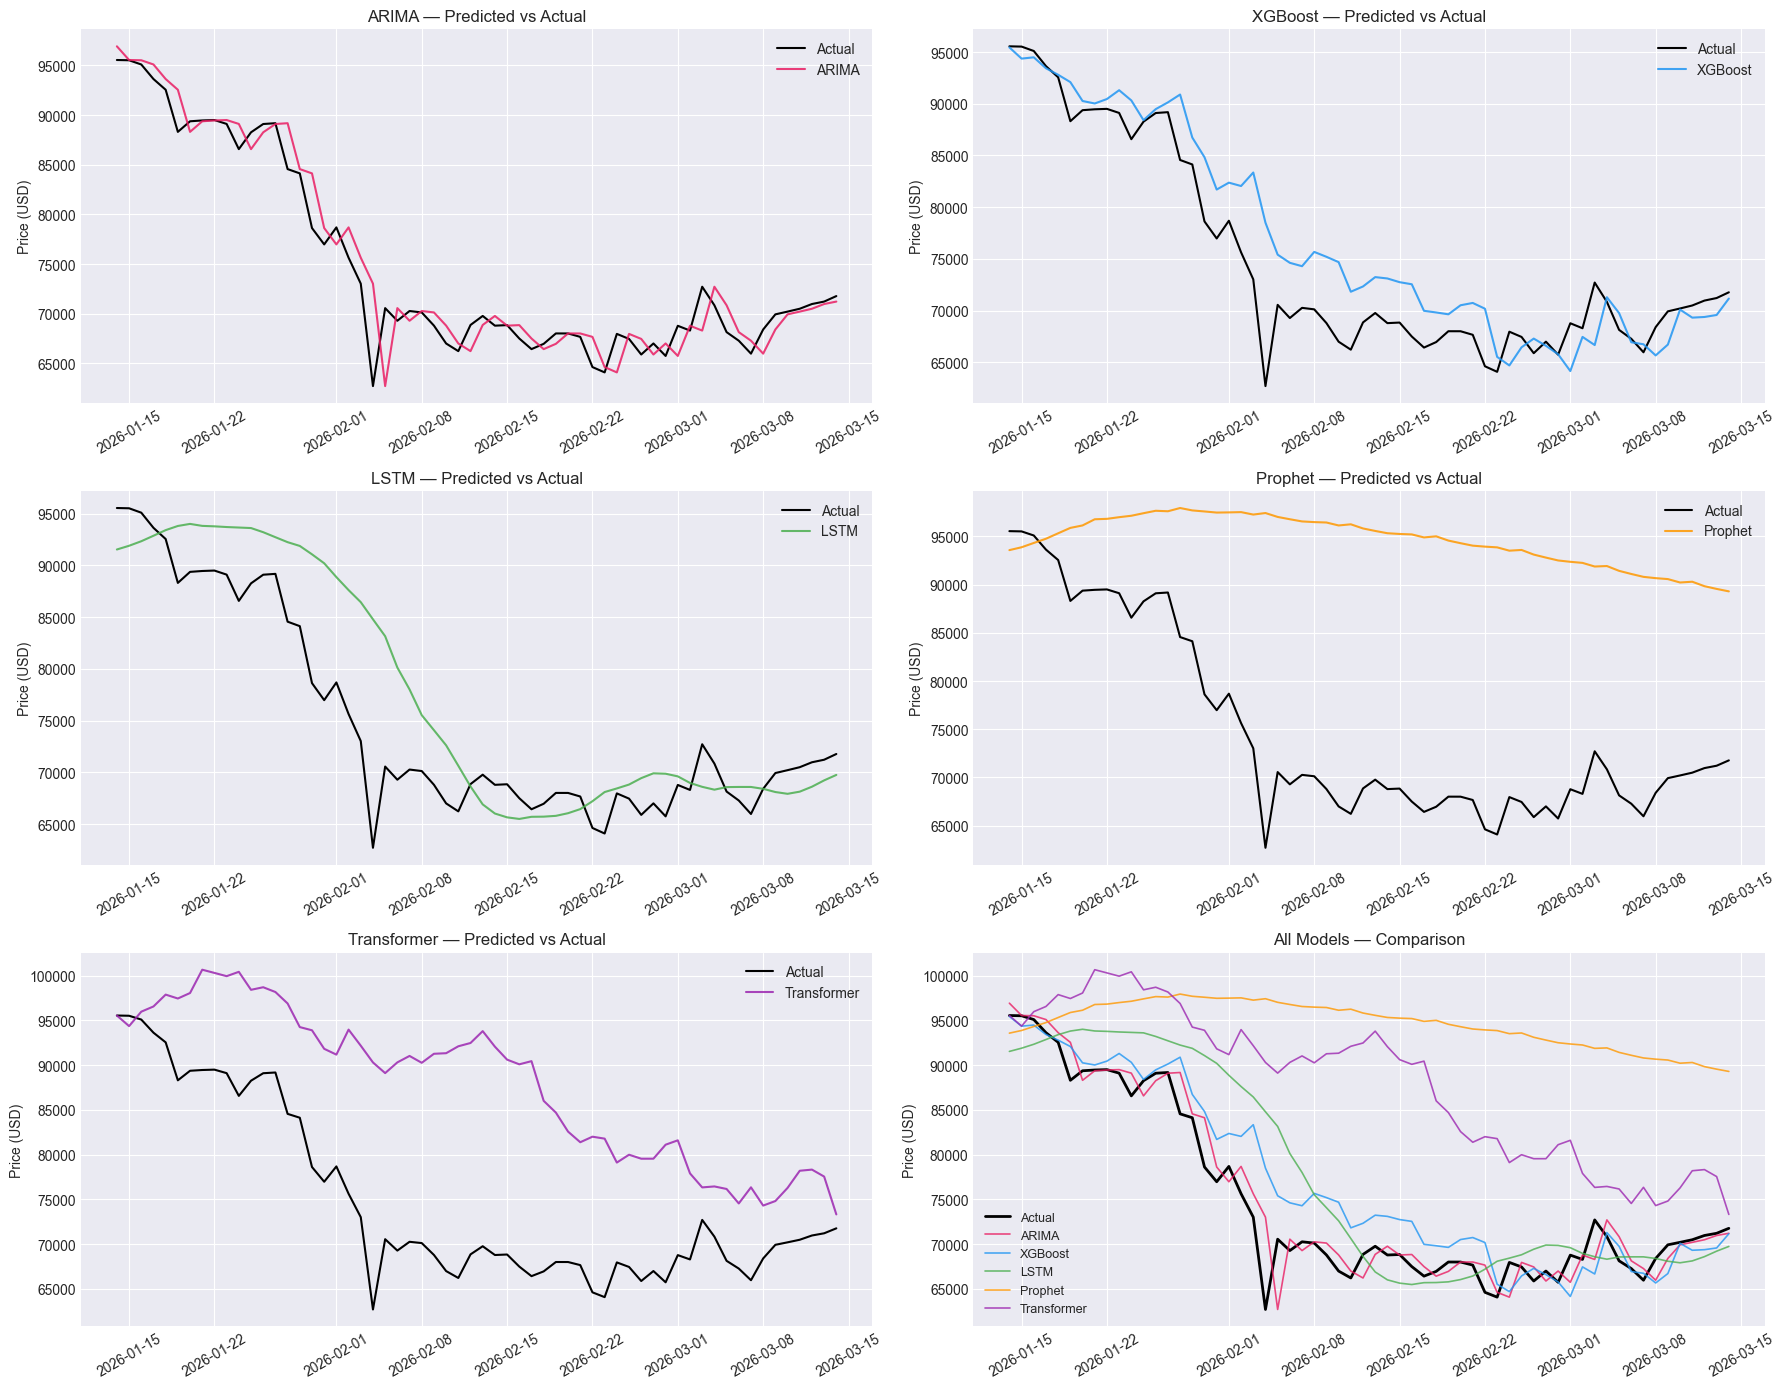

In [25]:
# Predictions vs Actual — all models
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

colors = {'ARIMA': '#E91E63', 'XGBoost': '#2196F3', 'LSTM': '#4CAF50', 'Prophet': '#FF9800', 'Transformer': '#9C27B0'}

common_len = min(len(y_test), min(len(p) for p in all_predictions.values()))
test_dates = y_test.index[:common_len]
y_actual = y_test.values[:common_len]

for idx, (name, preds) in enumerate(all_predictions.items()):
    ax = axes[idx]
    ax.plot(test_dates, y_actual, label='Actual', color='black', linewidth=1.5)
    ax.plot(test_dates, preds[:common_len], label=name, color=colors[name], linewidth=1.5, alpha=0.85)
    ax.set_title(f'{name} — Predicted vs Actual')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

# All models overlay
ax = axes[5]
ax.plot(test_dates, y_actual, label='Actual', color='black', linewidth=2)
for name, preds in all_predictions.items():
    ax.plot(test_dates, preds[:common_len], label=name, color=colors[name], linewidth=1.2, alpha=0.8)
ax.set_title('All Models — Comparison')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

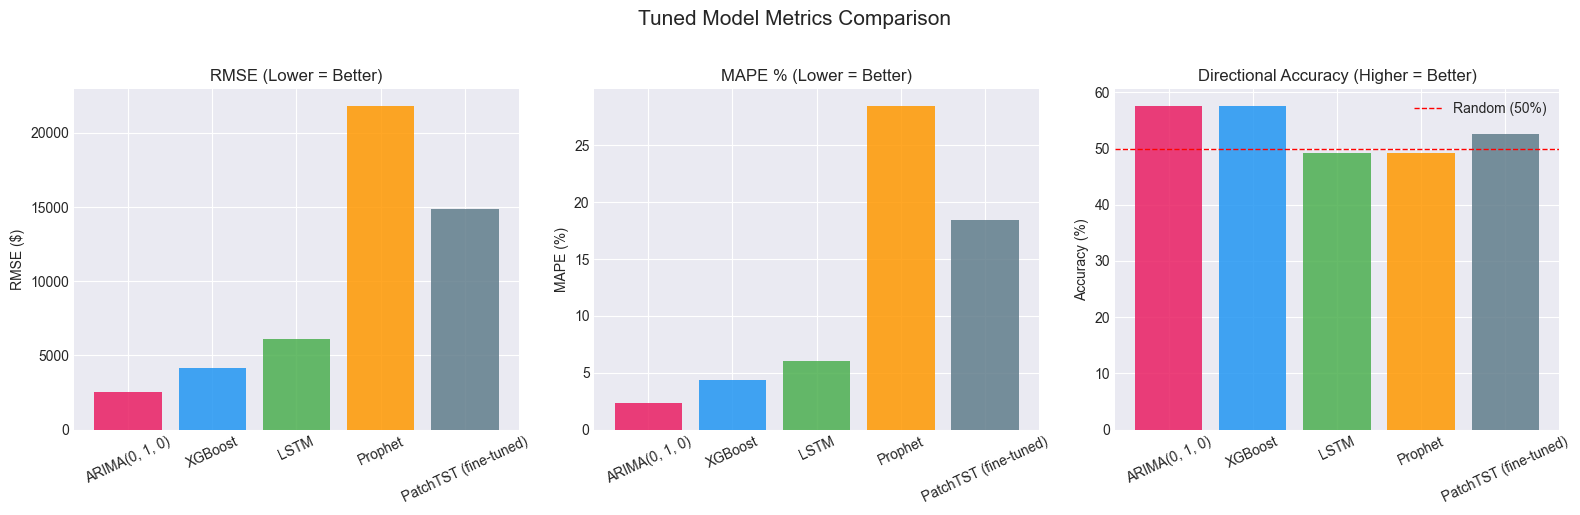

In [26]:
# Metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = results_df.index.tolist()
bar_colors = []
for m in model_names:
    matched = False
    for key, color in colors.items():
        if key in m:
            bar_colors.append(color)
            matched = True
            break
    if not matched:
        bar_colors.append('#607D8B')

axes[0].bar(model_names, results_df['RMSE'], color=bar_colors, alpha=0.85)
axes[0].set_title('RMSE (Lower = Better)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(model_names, results_df['MAPE'], color=bar_colors, alpha=0.85)
axes[1].set_title('MAPE % (Lower = Better)')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=25)

axes[2].bar(model_names, results_df['Dir_Accuracy'], color=bar_colors, alpha=0.85)
axes[2].axhline(y=50, color='red', linestyle='--', linewidth=1, label='Random (50%)')
axes[2].set_title('Directional Accuracy (Higher = Better)')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=25)

plt.suptitle('Tuned Model Metrics Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Observations

ARIMA winning as a random walk (`0,1,0`). XGBoost is the most practical pick here. Prophet struggles because BTC doesn't have the clean seasonality it's built for, and PatchTST needs more fine tuning to close the gap. No leakage — test split is time-ordered, scalers fit on train only, lags use `shift()`.

In [ ]:
# Save artifacts for production pipeline
df.to_csv('btc_usd_historical.csv')
results_df.to_csv('experiment_results.csv')

import json
with open('best_hyperparameters.json', 'w') as f:
    # Convert numpy types to native Python for JSON serialization
    serializable = {}
    for model, params in best_params.items():
        serializable[model] = {k: (int(v) if isinstance(v, (np.integer,)) else 
                                   float(v) if isinstance(v, (np.floating,)) else v)
                               for k, v in params.items()}
    json.dump(serializable, f, indent=2)

print("Saved:")
print("btc_usd_historical.csv")
print("experiment_results.csv")
print("best_hyperparameters.json")
print("\nExperiment notebook complete!")

Saved:
  btc_usd_historical.csv
  experiment_results.csv
  best_hyperparameters.json

Experiment notebook complete!


---
## 13. Save Trained Models -> Intelligence Layer

Persists every trained model to intelligence/models/artifacts/ so the production inference layer can load them directly without retraining.

In [30]:
import pickle
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA as StatsARIMA

ARTIFACTS_DIR = Path("../intelligence/models/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. ARIMA
print("Saving ARIMA ...")
arima_final = StatsARIMA(train_close, order=best_order).fit()
with open(ARTIFACTS_DIR / "arima_model.pkl", "wb") as f:
    pickle.dump({"model_result": arima_final, "close_series": train_close}, f)
print("arima_model.pkl")

# 2. XGBoost 
print("Saving XGBoost ...")
with open(ARTIFACTS_DIR / "xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_best, f)
print("xgboost_model.pkl")

#3. LSTM 
# Save Keras model + both scalers (keys 'feat' and 'tgt' match the loader).
print("Saving LSTM ...")
lstm_best_fresh.save(str(ARTIFACTS_DIR / "lstm_model.keras"))
with open(ARTIFACTS_DIR / "lstm_scalers.pkl", "wb") as f:
    pickle.dump({"feat": scaler_X, "tgt": scaler_y}, f)
print("lstm_model.keras + lstm_scalers.pkl")

# 4. Prophet
print("Saving Prophet ...")
with open(ARTIFACTS_DIR / "prophet_model.pkl", "wb") as f:
    pickle.dump(prophet_best, f)
print("prophet_model.pkl")


print(f"\nAll model artifacts saved to: {ARTIFACTS_DIR.resolve()}")

Saving ARIMA ...
arima_model.pkl
Saving XGBoost ...


c:\Users\sidde\OneDrive\Desktop\BIZ assignment\Backend\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sidde\OneDrive\Desktop\BIZ assignment\Backend\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sidde\OneDrive\Desktop\BIZ assignment\Backend\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


xgboost_model.pkl
Saving LSTM ...
lstm_model.keras + lstm_scalers.pkl
Saving Prophet ...
prophet_model.pkl

All model artifacts saved to: C:\Users\sidde\OneDrive\Desktop\BIZ assignment\Backend\intelligence\models\artifacts
